# 05 — Ambiguity flagship and interpretive meta-tokens

The frozen 120-item ambiguity set contains 30 lexical, 30 PP-attachment, 30 garden-path, and 30 pronoun cases. Each item has original and mirrored forced-choice probes. Commitment is defined by the mean counterbalanced clean margin without using a gold label or any intervention result. This phase is **diagnostic, not confirmatory**: upstream strict Qwen-7B G2 failed, and its raw $W_UJ$ known-case swap was not directionally usable. We preserve the preregistered mean-flip P3 verdict and additionally report the stricter rate at which both counterbalanced variants flip. Final concept-token suppression is structurally zero because concept IDs are disjoint from the A/B metric IDs; it is an instrumentation check, not extra causal evidence. Abstract English/Chinese meta-tokens remain diagnostic. READ is the independent mean absolute $\nabla M\cdot v$ projection; WRITE×READ products remain first-order diagnostics only.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
metrics_path = ROOT / 'results/metrics.json'
spec_path = ROOT / 'data/specs/ambiguity.json'
spec = json.loads(spec_path.read_text())
print('Frozen ambiguity items:', len(spec['items']))
print('Categories:', {category: sum(item['category'] == category for item in spec['items']) for category in sorted({item['category'] for item in spec['items']})})

Frozen ambiguity items: 120
Categories: {'ambiguous_pronoun': 30, 'garden_path': 30, 'lexical_ambiguity': 30, 'pp_attachment': 30}


In [2]:
from src.ambiguity_phase import run_qwen_ambiguity_phase

ambiguity = run_qwen_ambiguity_phase(
    spec_path=spec_path,
    output_path=ROOT / 'data/raw/05_ambiguity_qwen7b.json',
    figure_path=ROOT / 'results/figures/f8_ambiguity_write_read.png',
    device='cuda',
    direction_compute_device='cuda',
    max_length=256,
    output_top_k=10,
    lens_top_k=10,
    max_swap_condition=1e4,
    tie_tolerance=0.0,
    n_bootstrap=5000,
    fail_fast=False,
)
assert ambiguity['n_frozen_items'] == 120
assert ambiguity['analysis_role'] == 'diagnostic_upstream_strict_g2_failed'
print('Status counts:', ambiguity['p3']['status_counts'])
print('Analysis role:', ambiguity['analysis_role'])

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Status counts: {'OK': 120}
Analysis role: diagnostic_upstream_strict_g2_failed


## Curated metrics versus raw audit trail

`data/raw/05_ambiguity_qwen7b.json` keeps every clean variant, per-layer/per-position committed and alternate WRITE/READ array, token rank, and intervention record. `results/metrics.json` keeps every item's counterbalanced committed-versus-alternate WRITE and independent READ, real ablation/swap/suppression effects, both mean and counterbalance-robust swap flags, meta-token aggregates, commitment, control rejection, and failure status, while omitting only the repetitive raw variant tensors. Phase-level gate context and the structural-zero interpretation of output suppression are persisted with the curated result.

In [3]:
from src.metrics import save_json

base_keys = ('row_index', 'id', 'category', 'sentence', 'readings', 'concepts', 'workspace_layers', 'direction_method', 'direction_policy', 'measurement_status', 'commitment', 'direction_pair', 'rms_gain_fold_sensitivity')
slim_rows = []
for row in ambiguity['rows']:
    slim = {key: row[key] for key in base_keys if key in row}
    if 'counterbalanced' in row:
        slim['counterbalanced'] = row['counterbalanced']
    if 'meta_counterbalanced' in row:
        slim['meta_counterbalanced'] = row['meta_counterbalanced']
    for key in ('control_rejections', 'error_type', 'error'):
        if key in row:
            slim[key] = row[key]
    slim_rows.append(slim)
curated = {key: ambiguity[key] for key in ('schema_version', 'analysis_role', 'upstream_gate_context', 'output_suppression_control', 'seed', 'model', 'lens', 'spec_path', 'n_frozen_items', 'workspace_layers', 'direction_policy', 'direction_sensitivity', 'meta_token_preregistration', 'p3', 'meta_token_diagnostics', 'figures', 'run_configuration')}
curated['rows'] = slim_rows
metrics = json.loads(metrics_path.read_text())
metrics.setdefault('ambiguity', {})['qwen2.5-7b-instruct'] = curated
save_json(metrics_path, metrics)
print('Curated ambiguity merged; metrics size MiB:', metrics_path.stat().st_size / 2**20)

Curated ambiguity merged; metrics size MiB: 43.18282699584961


In [4]:
import pandas as pd

p3 = ambiguity['p3']
overall = p3['overall']['statistics']
display(pd.DataFrame([{
    'quantity': key,
    'estimate': value.get('estimate'),
    'ci_low': value.get('ci_low'),
    'ci_high': value.get('ci_high'),
    'status': value['status'],
} for key, value in overall.items()]))
measured_rows = [row for row in ambiguity['rows'] if row['measurement_status'] == 'OK']
role_rows = []
for row in measured_rows:
    role_rows.append({'item': row['id'], 'role': 'committed', 'WRITE': row['counterbalanced']['attribution']['committed_concept']['write_abs_mean'], 'READ': row['counterbalanced']['attribution']['committed_concept']['read_abs_mean']})
    role_rows.append({'item': row['id'], 'role': 'alternate', 'WRITE': row['counterbalanced']['attribution']['alternate_concept']['write_abs_mean'], 'READ': row['counterbalanced']['attribution']['alternate_concept']['read_abs_mean']})
display(pd.DataFrame(role_rows).groupby('role')[['WRITE', 'READ']].agg(['mean', 'median']))
display(pd.DataFrame([{
    'category': category,
    'n_measured': result['n'],
    'mean_swap_flip_rate': result['statistics']['swap_flip_rate'].get('estimate'),
    'both_variants_flip_rate': result['statistics']['counterbalance_robust_swap_flip_rate'].get('estimate'),
    'damage_gap': result['statistics']['internal_minus_suppression_damage'].get('estimate'),
} for category, result in p3['by_category'].items()]))
print('Diagnostic P3 verdict:', p3['verdict'])
print('Analysis role:', p3['analysis_role'])
print('Preserved mean-flip verdict rule:', p3['verdict_rule'])
print('Robust swap rule:', p3['counterbalance_robust_swap_rule'])
print('Output control:', p3['output_suppression_interpretation'])

,quantity,estimate,ci_low,ci_high,status
0,committed_concept_write_abs_mean,8.609111,8.082185,9.153804,ESTIMATED
1,alternate_concept_write_abs_mean,8.598790,8.043945,9.109349,ESTIMATED
2,committed_concept_read_abs_mean,0.013422,0.012545,0.014325,ESTIMATED
3,alternate_concept_read_abs_mean,0.013552,0.012679,0.014423,ESTIMATED
4,clean_committed_margin,9.160937,8.287487,10.011992,ESTIMATED
5,swap_edited_committed_margin,8.438802,7.619421,9.296628,ESTIMATED
6,swap_flip_rate,0.033333,0.013038,0.082580,ESTIMATED
7,counterbalance_robust_swap_flip_rate,0.000000,0.000000,0.031019,ESTIMATED
8,internal_ablation_positive_damage,1.151302,0.949479,1.357559,ESTIMATED
9,output_suppression_positive_damage,0.000000,0.000000,0.000000,ESTIMATED


WRITE                READ          
               mean    median      mean    median
role                                             
alternate  8.598790  8.287522  0.013552  0.013437
committed  8.609111  8.785595  0.013422  0.013297

,category,n_measured,mean_swap_flip_rate,both_variants_flip_rate,damage_gap
0,ambiguous_pronoun,30,0.033333,0.0,1.577083
1,garden_path,30,0.033333,0.0,0.586458
2,lexical_ambiguity,30,0.033333,0.0,0.985417
3,pp_attachment,30,0.033333,0.0,1.456250


Diagnostic P3 verdict: refuted
Analysis role: diagnostic_upstream_strict_g2_failed
Preserved mean-flip verdict rule: supported iff the 95% CI lower bound for swap-flip rate exceeds 0.5 and the CI lower bound for the damage gap exceeds 0; mixed iff both point criteria hold; otherwise refuted
Robust swap rule: edited committed margin after swap < 0 in both original and mirrored probes
Output control: {'status': 'STRUCTURAL_ZERO_NEGATIVE_CONTROL', 'expected_exact_zero': True, 'reason': 'Ambiguity tokenization requires both concept-token IDs to be disjoint from the A/B behavior-token IDs. Suppressing only a concept vocabulary logit cannot change the A-minus-B logit metric, so this control is exactly zero by construction.', 'evidential_role': 'Schema/instrumentation check only; the zero does not provide additional causal evidence beyond the internal intervention itself.', 'observed_all_exact_zero': True, 'observed_damage_gap_equals_ablation': True}


In [5]:
meta = ambiguity['meta_token_diagnostics']
display(pd.DataFrame([{
    'candidate': key,
    'language': result['candidate']['language'],
    'n': result['n_complete_items'],
    'WRITE': result['mean_abs_write'].get('estimate'),
    'READ': result['mean_independent_read_abs'].get('estimate'),
    'ablation_damage': result['mean_ablation_positive_damage'].get('estimate'),
    'corr_damage_READ': result['read_vs_ablation_damage'].get('estimate'),
    'partial_damage_READ_given_WRITE': result['partial_causal_read_given_write'].get('estimate'),
} for key, result in meta['by_candidate'].items()]))
print(meta['interpretation_warning'])

,candidate,language,n,WRITE,READ,ablation_damage,corr_damage_READ,partial_damage_READ_given_WRITE
0,interpretation_en,en,120,6.197022,0.013798,1.113542,0.018696,0.018669
1,meaning_en,en,120,3.620158,0.010679,0.149479,-0.002685,-0.010686
2,ambiguous_en,en,120,8.331267,0.014400,1.289583,0.109784,0.110035
3,ambiguity_en,en,120,9.586675,0.016062,1.472396,0.159040,0.159126
4,explain_zh,zh,120,8.824749,0.013975,0.187760,-0.167593,-0.168102
5,meaning_formal_zh,zh,120,11.225990,0.016102,1.496875,0.211382,0.216067
6,meaning_colloquial_zh,zh,120,9.494662,0.014896,0.938542,0.196204,0.197921
7,vague_zh,zh,120,12.059813,0.015879,1.799479,0.160966,0.166878
8,interpret_zh,zh,120,10.497933,0.014772,0.685677,-0.050074,-0.050131


These predeclared meta-token results are descriptive diagnostics. No candidate is selected or promoted based on WRITE, rank, or ablation outcomes, and they are not part of the confirmatory P3 verdict.


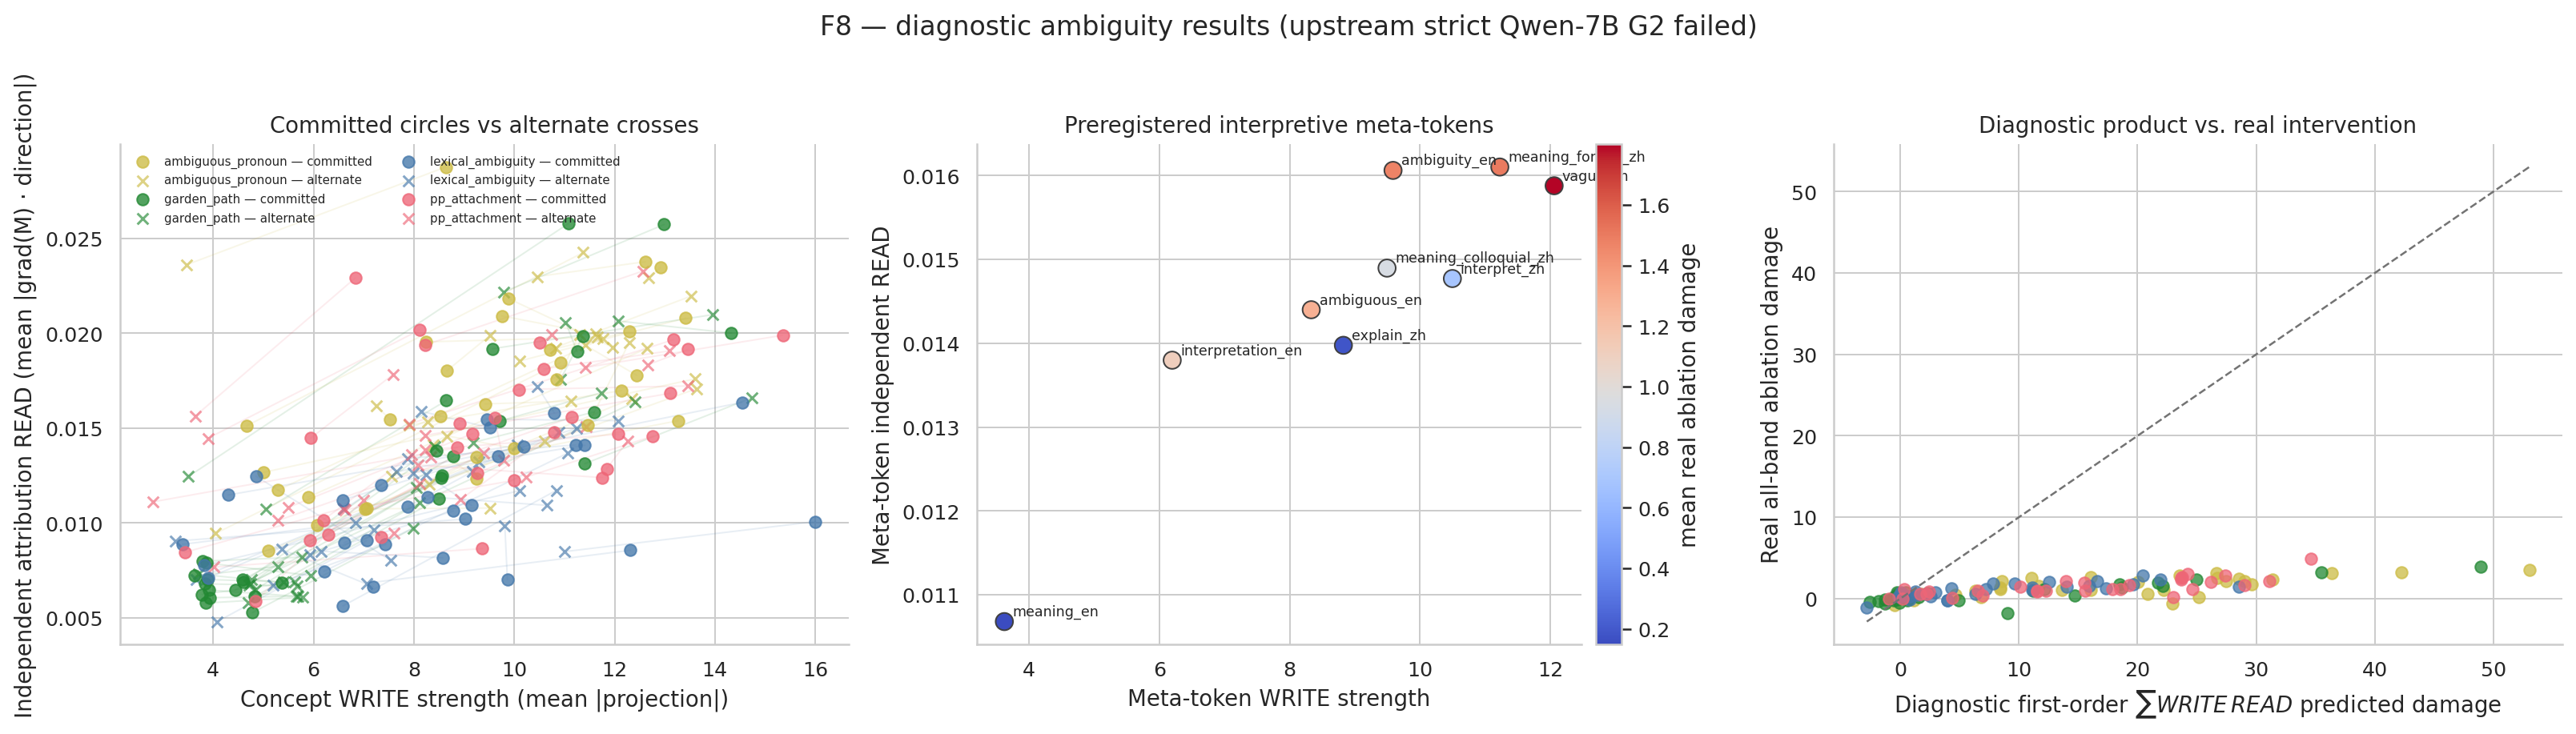

In [6]:
from IPython.display import Image, display

display(Image(filename=ambiguity['figures']['f8']))

In [7]:
print('PHASE 05 COMPUTED — DIAGNOSTIC (STRICT QWEN-7B G2 FAILED)')
print('P3 DIAGNOSTIC VERDICT', ambiguity['p3']['verdict'].upper())
print('Frozen/measured/status:', ambiguity['n_frozen_items'], ambiguity['p3']['overall']['n'], ambiguity['p3']['status_counts'])
print('Mean swap-flip rate:', ambiguity['p3']['overall']['statistics']['swap_flip_rate'].get('estimate'))
print('Both-variants swap-flip rate:', ambiguity['p3']['overall']['statistics']['counterbalance_robust_swap_flip_rate'].get('estimate'))
print('Output suppression is structurally zero for this disjoint-token A/B metric and is not extra causal evidence.')
print('Ambiguity uses raw J-Lens directions only; mean-difference robustness is not established for this phase.')

PHASE 05 COMPUTED — DIAGNOSTIC (STRICT QWEN-7B G2 FAILED)
P3 DIAGNOSTIC VERDICT REFUTED
Frozen/measured/status: 120 120 {'OK': 120}
Mean swap-flip rate: 0.03333333333333333
Both-variants swap-flip rate: 0.0
Output suppression is structurally zero for this disjoint-token A/B metric and is not extra causal evidence.
Ambiguity uses raw J-Lens directions only; mean-difference robustness is not established for this phase.
